# Practical No-02: Text Classification using Embedding Layer and LSTM

## SMS Spam Detection Using Embedding Layer and LSTM

### Objective
Build a text classification model for a binary classification task using an Embedding layer and an LSTM network. Evaluate the model performance using appropriate classification metrics.

### Student Information
- **Name:** Shreya Dattaram Bhosale
- **PRN Number:** 202502110010
- **Class:** T.Y. B.Tech
- **Course:** Generative AI Lab
- **Department:** CSE (AI & ML)
- **Batch:** A3
- **Date of Submission:** 09/09/2026

## Dataset
**SMS Spam Collection Dataset**

- `ham` = legitimate SMS
- `spam` = unwanted/spam SMS
- Task = Binary text classification
- Model = Embedding → LSTM → Dropout → Dense (Sigmoid)

The notebook includes data exploration, preprocessing, model building, training, evaluation, visualization, and prediction on new SMS messages.


In [ ]:
# Install required packages if needed
# Run this cell once if any package is missing.

%pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn

In [ ]:
# Import libraries

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Download / Load the Dataset

This cell downloads the official SMS Spam Collection file automatically if it is not already present.

If internet access is unavailable, download the `SMSSpamCollection` file manually and place it in the same folder as this notebook.

In [ ]:
# Download dataset automatically if it is not present

import urllib.request
import zipfile

dataset_file = "SMSSpamCollection"
zip_file = "smsspamcollection.zip"
dataset_url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

if not os.path.exists(dataset_file):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_file)

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(".")

    print("Dataset downloaded and extracted.")
else:
    print("Dataset already exists.")

data = pd.read_csv(
    dataset_file,
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="latin-1"
)

print("Dataset loaded successfully.")
print("Shape:", data.shape)
data.head()

Dataset downloaded and extracted.
Dataset loaded successfully.
Shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 2. Basic Dataset Exploration

In [ ]:
print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nClass distribution:")
print(data["label"].value_counts())

print("\nFirst five records:")
display(data.head())

Dataset shape: (5572, 2)

Columns:
['label', 'message']

Missing values:
label      0
message    0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

First five records:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Remove any unexpected missing rows

data = data.dropna(subset=["label", "message"]).copy()

# Keep only the two required classes
data = data[data["label"].isin(["ham", "spam"])].copy()

print("Shape after cleaning:", data.shape)
print(data["label"].value_counts())

Shape after cleaning: (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


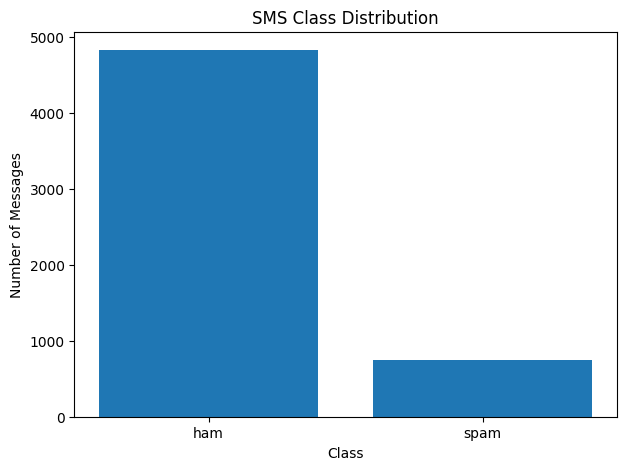

In [ ]:
# Visualize class distribution

class_counts = data["label"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("SMS Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Messages")
plt.show()

## 3. Data Preprocessing

The messages are cleaned by:
- converting text to lowercase
- removing URLs
- removing punctuation/special characters
- removing extra spaces

The original messages are retained in `message` and the cleaned text is stored in `clean_message`.

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["clean_message"] = data["message"].apply(clean_text)

# Convert labels to numbers
data["label_id"] = data["label"].map({"ham": 0, "spam": 1})

display(data[["label", "message", "clean_message", "label_id"]].head())

,label,message,clean_message,label_id
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...,1
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...,0


## 4. Separate Input and Target

In [ ]:
X = data["clean_message"].values
y = data["label_id"].values

print("Number of messages:", len(X))
print("Number of labels:", len(y))

Number of messages: 5572
Number of labels: 5572


## 5. Train-Test Split

An 80:20 split is used. `stratify=y` preserves the class distribution in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts())

Training samples: 4457
Testing samples: 1115

Training class distribution:
0    3859
1     598
Name: count, dtype: int64

Testing class distribution:
0    966
1    149
Name: count, dtype: int64


## 6. Tokenization

The tokenizer converts words into integer IDs. The tokenizer is fitted **only on training data** to avoid data leakage.

In [ ]:
VOCAB_SIZE = 5000
MAX_LENGTH = 50

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Example original text:")
print(X_train[0])

print("\nExample tokenized sequence:")
print(X_train_seq[0])

print("\nVocabulary size learned:", len(tokenizer.word_index))

Example original text:
he will you guys close

Example tokenized sequence:
[68, 36, 4, 338, 656]

Vocabulary size learned: 7647


## 7. Padding

LSTM inputs must have a consistent sequence length. All messages are padded/truncated to 50 tokens.

In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (4457, 50)
Testing shape: (1115, 50)


## 8. Build the Embedding + LSTM Model

### Architecture
`Input sequence → Embedding → LSTM → Dropout → Dense(Sigmoid)`

- **Embedding:** learns a dense vector representation for each word.
- **LSTM:** learns sequential patterns in the message.
- **Dropout:** helps reduce overfitting.
- **Sigmoid:** outputs a probability for the spam class.

In [ ]:
EMBEDDING_DIM = 64
LSTM_UNITS = 64

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        name="embedding"
    ),
    LSTM(
        LSTM_UNITS,
        name="lstm"
    ),
    Dropout(
        0.30,
        name="dropout"
    ),
    Dense(
        1,
        activation="sigmoid",
        name="output"
    )
])

model.build(input_shape=(None, MAX_LENGTH))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,089 (1.35 MB)

 Trainable params: 353,089 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile the Model

Because this is binary classification, `binary_crossentropy` is used as the loss function. Adam is used as the optimizer.

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## 10. Train the Model

Early stopping restores the best validation model and helps prevent unnecessary training.

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - accuracy: 0.8875 - loss: 0.3294 - val_accuracy: 0.9563 - val_loss: 0.2111
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.9627 - loss: 0.1652 - val_accuracy: 0.9462 - val_loss: 0.2148
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9663 - loss: 0.1535 - val_accuracy: 0.9496 - val_loss: 0.2030
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9750 - loss: 0.1190 - val_accuracy: 0.9574 - val_loss: 0.1830
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9778 - loss: 0.1110 - val_accuracy: 0.9608 - val_loss: 0.1727
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9849 - loss: 0.0793 - val_accuracy: 0.9608 - val_loss: 0.1728
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9877 - loss: 0.0664 - val_accuracy: 0.9697 - val_loss: 0.1512
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9891 - loss: 0.0616 - val_a

## 11. Plot Training and Validation Accuracy

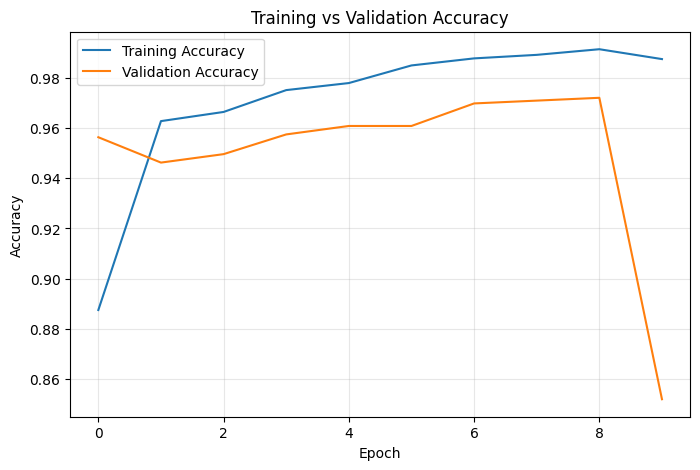

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 12. Plot Training and Validation Loss

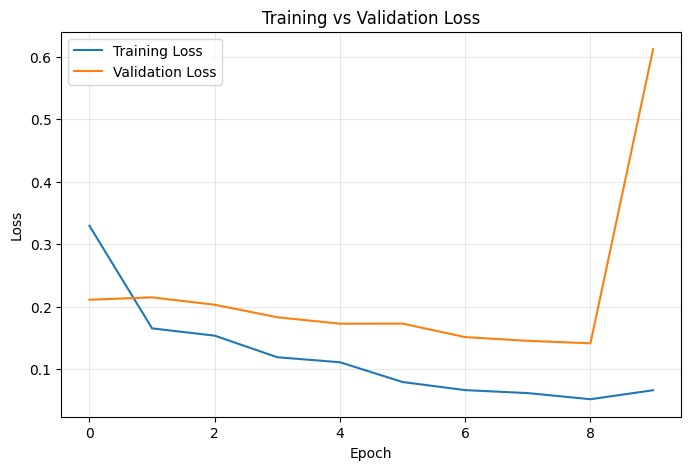

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. Evaluate on the Unseen Test Set

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9758 - loss: 0.1233

Test Loss: 0.1233
Test Accuracy: 0.9758


## 14. Generate Predictions

In [ ]:
y_probability = model.predict(
    X_test_pad,
    verbose=0
).ravel()

y_pred = (y_probability >= 0.5).astype(int)

print("Predictions generated.")
print("First 10 predicted labels:", y_pred[:10])
print("First 10 actual labels:", y_test[:10])

Predictions generated.
First 10 predicted labels: [0 0 0 1 0 0 0 0 0 0]
First 10 actual labels: [0 0 0 1 0 0 0 0 0 0]


## 15. Classification Metrics

The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1-score

For spam detection, precision and recall are important because false spam predictions and missed spam messages have different consequences.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

display(metrics_df.style.format({"Score": "{:.4f}"}))

,Metric,Score
0,Accuracy,0.9758
1,Precision,0.9420
2,Recall,0.8725
3,F1-Score,0.9059


## 16. Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.94      0.87      0.91       149

    accuracy                           0.98      1115
   macro avg       0.96      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



## 17. Confusion Matrix

The confusion matrix shows:
- True Negative (TN)
- False Positive (FP)
- False Negative (FN)
- True Positive (TP)

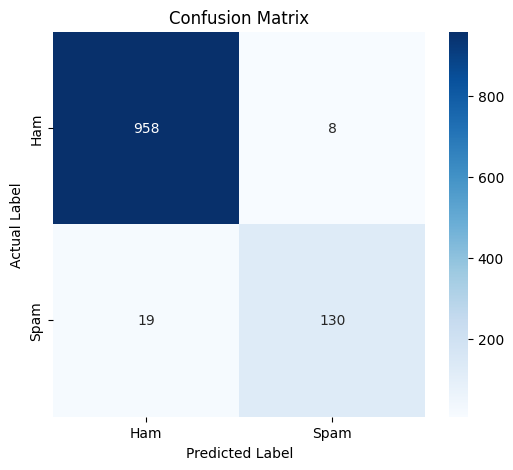

Confusion Matrix:
[[958   8]
 [ 19 130]]


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

print("Confusion Matrix:")
print(cm)

## 18. Test the Model on New SMS Messages

This function allows a user to enter a new SMS and receive:
- predicted class
- spam probability

In [ ]:
def predict_message(message):
    cleaned = clean_text(message)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probability = float(
        model.predict(padded, verbose=0)[0][0]
    )

    if probability >= 0.5:
        prediction = "SPAM"
    else:
        prediction = "HAM"

    return prediction, probability

# Example 1
message1 = "Congratulations! You have won a free prize. Call now!"
prediction1, probability1 = predict_message(message1)

print("Message:", message1)
print("Prediction:", prediction1)
print("Spam probability:", round(probability1, 4))

print()

# Example 2
message2 = "Hi, are we meeting for the project today?"
prediction2, probability2 = predict_message(message2)

print("Message:", message2)
print("Prediction:", prediction2)
print("Spam probability:", round(probability2, 4))

Message: Congratulations! You have won a free prize. Call now!
Prediction: SPAM
Spam probability: 0.9913

Message: Hi, are we meeting for the project today?
Prediction: HAM
Spam probability: 0.0087


## 19. Interactive SMS Prediction

Enter your own SMS below. Type `exit` to stop.

In [ ]:
# NOTE: This cell is interactive and expects manual input.

try:
    while True:
        message = input("\nEnter an SMS message (or type 'exit'): ").strip()

        if message.lower() == "exit":
            print("Program ended.")
            break

        if not message:
            print("Please enter a message.")
            continue

        prediction, probability = predict_message(message)

        print("Prediction:", prediction)
        print("Spam probability:", round(probability, 4))
except EOFError:
    print("No interactive input available (running in a non-interactive environment). Skipping.")



Enter an SMS message (or type 'exit'): You have been selected for a cash reward of 5000 pounds. Call now to claim your prize.
Prediction: SPAM
Spam probability: 0.9913

Enter an SMS message (or type 'exit'): Please bring your notebook to class tomorrow.
Prediction: HAM
Spam probability: 0.0087

Enter an SMS message (or type 'exit'): URGENT: Please verify your account to continue using the service.
Prediction: SPAM
Spam probability: 0.9913

Enter an SMS message (or type 'exit'): The meeting has been postponed to 3 PM.
Prediction: HAM
Spam probability: 0.0087

Enter an SMS message (or type 'exit'): exit
Program ended.


## 20. Conclusion

The SMS Spam Detection model successfully performs binary text classification using an Embedding layer and an LSTM network. Text preprocessing, tokenization, sequence padding, model training, and evaluation were implemented as a complete machine learning pipeline.

The model was evaluated using accuracy, precision, recall, F1-score, classification report, and confusion matrix. Training and validation curves were also plotted to study model learning behavior.

The final interactive section demonstrates how the trained model can classify new SMS messages as **Ham** or **Spam**.

### Key Learning Outcomes
1. Text preprocessing for deep learning.
2. Conversion of text into numerical sequences.
3. Use of an Embedding layer for word representations.
4. Use of LSTM for sequential text learning.
5. Binary classification using sigmoid activation.
6. Evaluation using multiple classification metrics.
7. Practical prediction on unseen text.

## 21. Declaration

I, **Shreya Dattaram Bhosale**, confirm that the work submitted in this assignment is my own and has been completed following academic integrity guidelines.

**GitHub Repository Link:** https://github.com/bhosaleshreya25/Generative-AI/tree/main/Practical_No-02

**Signature:** Shreya Dattaram Bhosale
